In [1]:
import keras
from  keras.datasets import mnist
import matplotlib.pyplot as plt

2026-02-04 20:08:50.091697: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 20:08:50.275140: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/ros/rolling/opt/rviz_ogre_vendor/lib:/opt/ros/rolling/lib/x86_64-linux-gnu:/opt/ros/rolling/lib
2026-02-04 20:08:50.275160: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-04 20:08:50.318770: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for 

In [2]:
from keras.preprocessing.image  import ImageDataGenerator

In [3]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [4]:
train_images = train_images.astype('float32')/255.0 ## 78/255 = 0.305882353 --> 0
test_images = test_images.astype('float32')/255.0

In [5]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [6]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [7]:
len(train_images)

60000

In [8]:
datagen = ImageDataGenerator(rotation_range=45)

In [9]:
generated_data = datagen.flow(train_images, train_labels, batch_size=1000)

In [10]:
batches = generated_data
batch_0 = batches[0]

In [11]:
len(batch_0)

2

In [12]:
len(batch_0[0]) #---> images

1000

In [13]:
batch_0[0].shape

(1000, 28, 28, 1)

In [14]:
len(batch_0[1]) #-------> labels

1000

In [15]:
len(batches)

60

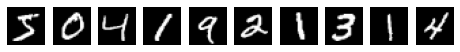

In [16]:
train_images_sample = train_images[0:10]
train_labels_sample = train_labels[0:10]
generated_data_sample = datagen.flow(train_images_sample, train_labels_sample, batch_size=10)

rows = 1
columns = 10

fig = plt.figure(figsize=(8, 8))

for i in range(1, 11):
    img = train_images_sample[i-1]
    fig.add_subplot(rows, columns, i)
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()



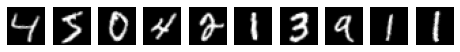

In [17]:
rows = 1
columns = 10

fig = plt.figure(figsize=(8, 8))
for i in range(1, 11):
    img = generated_data_sample[0][0][i-1]
    fig.add_subplot(rows, columns, i)
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

In [18]:
import numpy as np
concatenated_train_images = np.concatenate((train_images, generated_data[0][0]), axis=0)
concatenated_train_labels = np.concatenate((train_labels, generated_data[0][1]), axis=0)


In [19]:
concatenated_train_images.shape

(61000, 28, 28, 1)

In [20]:
concatenated_train_labels.shape

(61000, 10)

In [21]:
from keras.models import Sequential
from keras import layers

In [22]:
model = Sequential()
model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu',
                        strides=(1, 1), input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu',strides=(1, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', strides=(1, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

2026-02-04 20:08:55.240077: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/ros/rolling/opt/rviz_ogre_vendor/lib:/opt/ros/rolling/lib/x86_64-linux-gnu:/opt/ros/rolling/lib
2026-02-04 20:08:55.240116: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-04 20:08:55.240139: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (mhmud): /proc/driver/nvidia/version does not exist
2026-02-04 20:08:55.240428: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(concatenated_train_images, concatenated_train_labels, validation_split=0.1, verbose=1, epochs=3, batch_size=32)

Epoch 1/3
1716/1716 [==============================] - 65s 37ms/step - loss: 0.1243 - accuracy: 0.9605 - val_loss: 0.1159 - val_accuracy: 0.9669
Epoch 2/3
1716/1716 [==============================] - 76s 44ms/step - loss: 0.0474 - accuracy: 0.9847 - val_loss: 0.1187 - val_accuracy: 0.9661
Epoch 3/3
1716/1716 [==============================] - 72s 42ms/step - loss: 0.0366 - accuracy: 0.9883 - val_loss: 0.1286 - val_accuracy: 0.9689


In [24]:
model.save('mnist_epoch1_61000.h5')

In [25]:
!pwd

/home/mhmud/Desktop


In [26]:
loaded_model = keras.models.load_model('mnist_epoch1_61000.h5')

In [27]:
import cv2
test_img = cv2.imread('five.png', cv2.IMREAD_GRAYSCALE)
test_img_resized = cv2.resize(test_img, (28, 28))
test_img_flatten = test_img_resized.reshape(-1, 28, 28, 1)
test_img_normalized = test_img_flatten.astype('float32')/255.0
pred = loaded_model.predict(test_img_normalized)
pred_label = np.argmax(pred)
pred_label

1/1 [==============================] - 0s 257ms/step


5

In [28]:
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 14, 14, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                        

In [29]:
for layer in loaded_model.layers:
    print(layer)

In [30]:
feature_extractor = keras.models.Model(inputs=loaded_model.input, outputs=loaded_model.layers[-3].output)

In [31]:
feature_extractor.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_input (InputLayer)   [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 14, 14, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0     

In [32]:
model1 = Sequential()
model1.add(feature_extractor)
model1.add(layers.Conv2D(528, (1, 1), activation='relu'))
model1.add(layers.Flatten())
model1.add(layers.Dense(10, activation='softmax'))

In [33]:
for layer in feature_extractor.layers:
    layer.trainable=False #freeze!

In [34]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.fit(concatenated_train_images, concatenated_train_labels, validation_split=0.1, verbose=1, epochs=3, batch_size=32)

Epoch 1/3
1716/1716 [==============================] - 30s 17ms/step - loss: 0.0493 - accuracy: 0.9846 - val_loss: 0.1173 - val_accuracy: 0.9700
Epoch 2/3
1716/1716 [==============================] - 28s 16ms/step - loss: 0.0268 - accuracy: 0.9917 - val_loss: 0.1269 - val_accuracy: 0.9684
Epoch 3/3
1716/1716 [==============================] - 30s 17ms/step - loss: 0.0199 - accuracy: 0.9938 - val_loss: 0.1216 - val_accuracy: 0.9718


In [35]:
model2 = Sequential()
model2.add(feature_extractor)
model2.add(layers.Conv2D(528, (1, 1), activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(10, activation='softmax'))

In [36]:
for layer in feature_extractor.layers:
    layer.trainable=True

In [37]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.fit(concatenated_train_images, concatenated_train_labels, validation_split=0.1, verbose=1, epochs=3, batch_size=32)

Epoch 1/3
1716/1716 [==============================] - 80s 46ms/step - loss: 0.0577 - accuracy: 0.9816 - val_loss: 0.1457 - val_accuracy: 0.9631
Epoch 2/3
1716/1716 [==============================] - 84s 49ms/step - loss: 0.0347 - accuracy: 0.9895 - val_loss: 0.1154 - val_accuracy: 0.9689
Epoch 3/3
1716/1716 [==============================] - 72s 42ms/step - loss: 0.0292 - accuracy: 0.9910 - val_loss: 0.1329 - val_accuracy: 0.9692


In [59]:
#resnet 50
import tensorflow as tf
pretrained_model_resnet50 = tf.keras.applications.ResNet50(include_top=False,weights="imagenet",input_shape=(32, 32, 3))

In [60]:
pretrained_model_resnet50.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 38, 38, 3)    0           ['input_6[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 16, 16, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 16, 16, 64)   256         ['conv1_conv[0][0]']             
                                                                                           

                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 8, 8, 64)    256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 8, 8, 64)    0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 8, 8, 256)    16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_block3_3_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv2_block3_3_conv[0][0]']    
 ization) 

                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 4, 4, 128)   512         ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 4, 4, 128)   0           ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 4, 4, 512)    66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_block3_3_bn (BatchNormal  (None, 4, 4, 512)   2048        ['conv3_block3_3_conv[0][0]']    
 ization) 

                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 2, 2, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 2, 2, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 2, 2, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_block2_3_bn (BatchNormal  (None, 2, 2, 1024)  4096        ['conv4_block2_3_conv[0][0]']    
 ization) 

 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 2, 2, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 2, 2, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 2, 2, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
                                                                                                  
 conv4_blo

 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 1, 1, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 1, 1, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 1, 1, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
                                                                                                  
 conv5_blo

In [61]:
for layer in pretrained_model_resnet50.layers:
    layer.trainable=False

In [62]:
model3 = Sequential()
model3.add(pretrained_model_resnet50)
model3.add(layers.Conv2D(528, (1, 1), activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(10, activation='softmax'))

In [63]:
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.fit(concatenated_train_images, concatenated_train_labels, validation_split=0.1, verbose=1, epochs=1, batch_size=32)

ValueError: in user code:

    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/engine/training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/engine/training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/engine/training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/engine/training.py", line 993, in train_step
        y_pred = self(x, training=True)
    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/home/mhmud/.local/lib/python3.10/site-packages/keras/engine/input_spec.py", line 295, in assert_input_compatibility
        raise ValueErr

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow
